In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report

In [ ]:
(X_train, y_train), (X_test, y_test) = tf.keras.datasets.fashion_mnist.load_data()

print("Training:", X_train.shape)
print("Testing:", X_test.shape)

29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step
Training: (60000, 28, 28)
Testing: (10000, 28, 28)


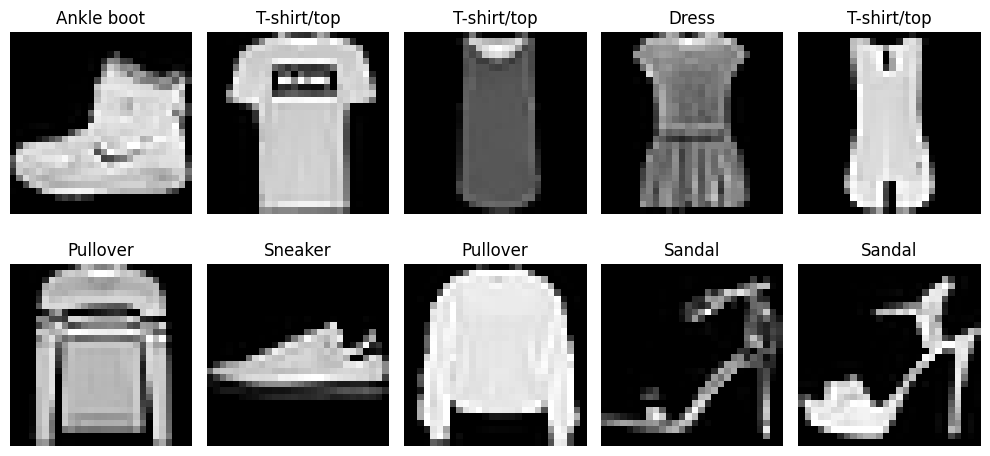

In [ ]:
classes = ["T-shirt/top", "Trouser", "Pullover", "Dress", "Coat",
           "Sandal", "Shirt", "Sneaker", "Bag", "Ankle boot"]

plt.figure(figsize=(10,5))
for i in range(10):
    plt.subplot(2,5,i+1)
    plt.imshow(X_train[i], cmap="gray")
    plt.title(classes[y_train[i]])
    plt.axis("off")
plt.tight_layout()
plt.show()

In [ ]:
X_train = X_train.astype("float32") / 255.0
X_test = X_test.astype("float32") / 255.0

X_train = X_train.reshape(-1,28,28,1)
X_test = X_test.reshape(-1,28,28,1)

X_val = X_train[-5000:]
y_val = y_train[-5000:]

X_train = X_train[:-5000]
y_train = y_train[:-5000]

print("Training:", X_train.shape)
print("Validation:", X_val.shape)
print("Testing:", X_test.shape)

Training: (55000, 28, 28, 1)
Validation: (5000, 28, 28, 1)
Testing: (10000, 28, 28, 1)


In [ ]:
model = Sequential([
    Conv2D(32, (3,3), activation="relu", input_shape=(28,28,1)),
    MaxPooling2D((2,2)),
    Conv2D(64, (3,3), activation="relu"),
    MaxPooling2D((2,2)),
    Flatten(),
    Dense(128, activation="relu"),
    Dropout(0.5),
    Dense(10, activation="softmax")
])

model.summary()

/usr/local/lib/python3.13/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1600)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       204,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 225,034 (879.04 KB)

 Trainable params: 225,034 (879.04 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=10,
    batch_size=64
)

Epoch 1/10
860/860 ━━━━━━━━━━━━━━━━━━━━ 28s 31ms/step - accuracy: 0.7728 - loss: 0.6295 - val_accuracy: 0.8568 - val_loss: 0.3858
Epoch 2/10
860/860 ━━━━━━━━━━━━━━━━━━━━ 40s 30ms/step - accuracy: 0.8545 - loss: 0.4133 - val_accuracy: 0.8792 - val_loss: 0.3251
Epoch 3/10
860/860 ━━━━━━━━━━━━━━━━━━━━ 26s 31ms/step - accuracy: 0.8724 - loss: 0.3558 - val_accuracy: 0.8864 - val_loss: 0.3083
Epoch 4/10
860/860 ━━━━━━━━━━━━━━━━━━━━ 26s 31ms/step - accuracy: 0.8825 - loss: 0.3239 - val_accuracy: 0.8998 - val_loss: 0.2717
Epoch 5/10
860/860 ━━━━━━━━━━━━━━━━━━━━ 26s 31ms/step - accuracy: 0.8922 - loss: 0.2976 - val_accuracy: 0.9028 - val_loss: 0.2685
Epoch 6/10
860/860 ━━━━━━━━━━━━━━━━━━━━ 41s 31ms/step - accuracy: 0.8980 - loss: 0.2791 - val_accuracy: 0.9002 - val_loss: 0.2642
Epoch 7/10
860/860 ━━━━━━━━━━━━━━━━━━━━ 26s 30ms/step - accuracy: 0.9041 - loss: 0.2632 - val_accuracy: 0.9086 - val_loss: 0.2463
Epoch 8/10
860/860 ━━━━━━━━━━━━━━━━━━━━ 42s 31ms/step - accuracy: 0.9080 - loss: 0.2478 - 

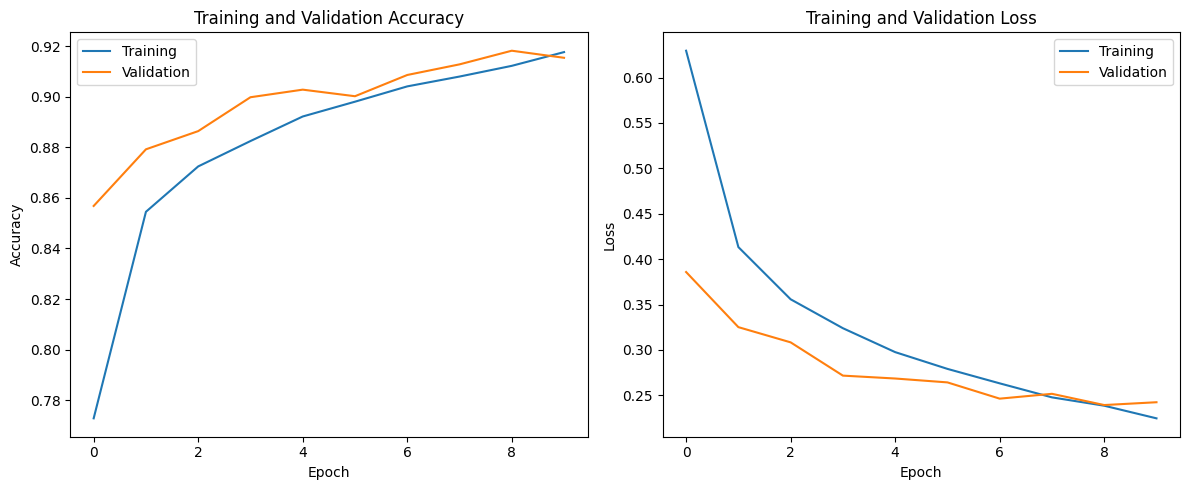

In [ ]:
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.plot(history.history["accuracy"], label="Training")
plt.plot(history.history["val_accuracy"], label="Validation")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training and Validation Accuracy")
plt.legend()

plt.subplot(1,2,2)
plt.plot(history.history["loss"], label="Training")
plt.plot(history.history["val_loss"], label="Validation")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training and Validation Loss")
plt.legend()

plt.tight_layout()
plt.show()

In [ ]:
test_loss, test_acc = model.evaluate(X_test, y_test, verbose=0)

y_prob = model.predict(X_test, verbose=0)
y_pred = np.argmax(y_prob, axis=1)

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, average="weighted")
recall = recall_score(y_test, y_pred, average="weighted")
f1 = f1_score(y_test, y_pred, average="weighted")

print("Accuracy :", accuracy)
print("Precision:", precision)
print("Recall   :", recall)
print("F1-Score :", f1)

Accuracy : 0.9069
Precision: 0.9073289047109554
Recall   : 0.9069
F1-Score : 0.9068444346490309


In [ ]:
print(classification_report(
    y_test,
    y_pred,
    target_names=classes
))

              precision    recall  f1-score   support

 T-shirt/top       0.85      0.86      0.86      1000
     Trouser       1.00      0.97      0.99      1000
    Pullover       0.82      0.88      0.85      1000
       Dress       0.91      0.92      0.91      1000
        Coat       0.87      0.83      0.85      1000
      Sandal       0.99      0.98      0.98      1000
       Shirt       0.74      0.71      0.73      1000
     Sneaker       0.94      0.98      0.96      1000
         Bag       0.98      0.97      0.98      1000
  Ankle boot       0.98      0.94      0.96      1000

    accuracy                           0.91     10000
   macro avg       0.91      0.91      0.91     10000
weighted avg       0.91      0.91      0.91     10000



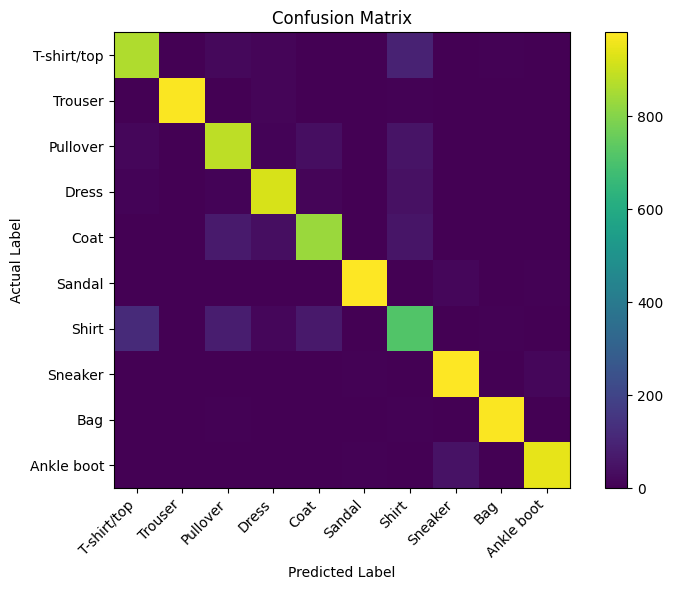

In [ ]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(8,6))
plt.imshow(cm)
plt.colorbar()
plt.xticks(range(10), classes, rotation=45, ha="right")
plt.yticks(range(10), classes)
plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")
plt.title("Confusion Matrix")
plt.tight_layout()
plt.show()

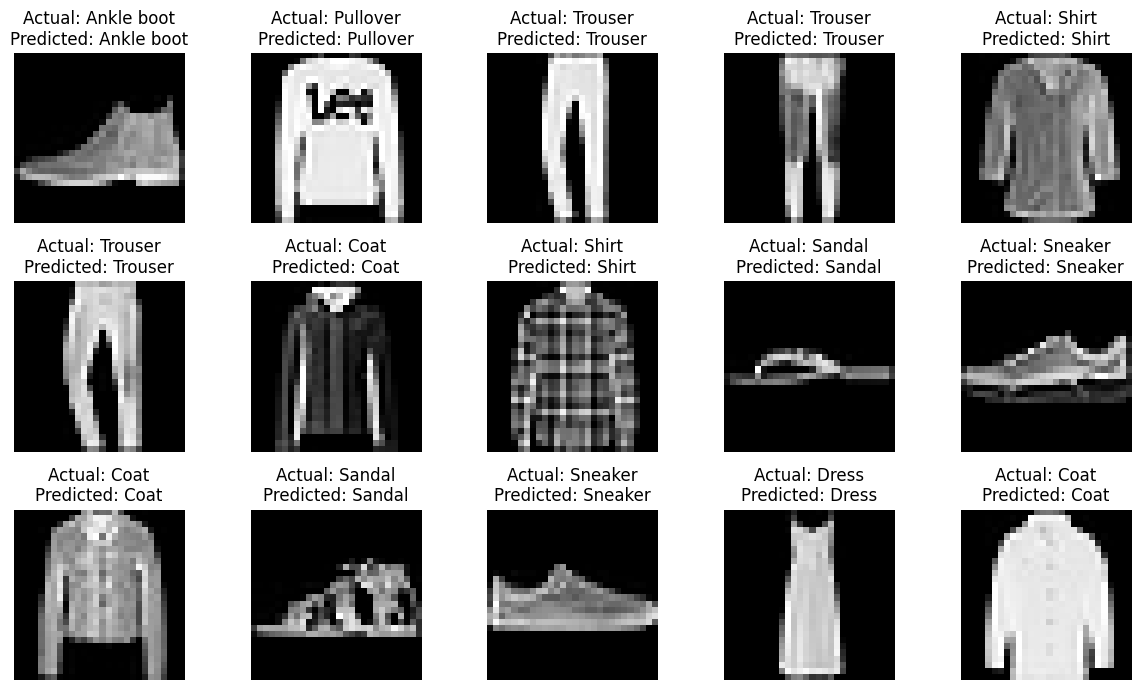

In [ ]:
plt.figure(figsize=(12,7))

for i in range(15):
    plt.subplot(3,5,i+1)
    plt.imshow(X_test[i].reshape(28,28), cmap="gray")
    plt.title("Actual: " + classes[y_test[i]] +
              "\nPredicted: " + classes[y_pred[i]])
    plt.axis("off")

plt.tight_layout()
plt.show()

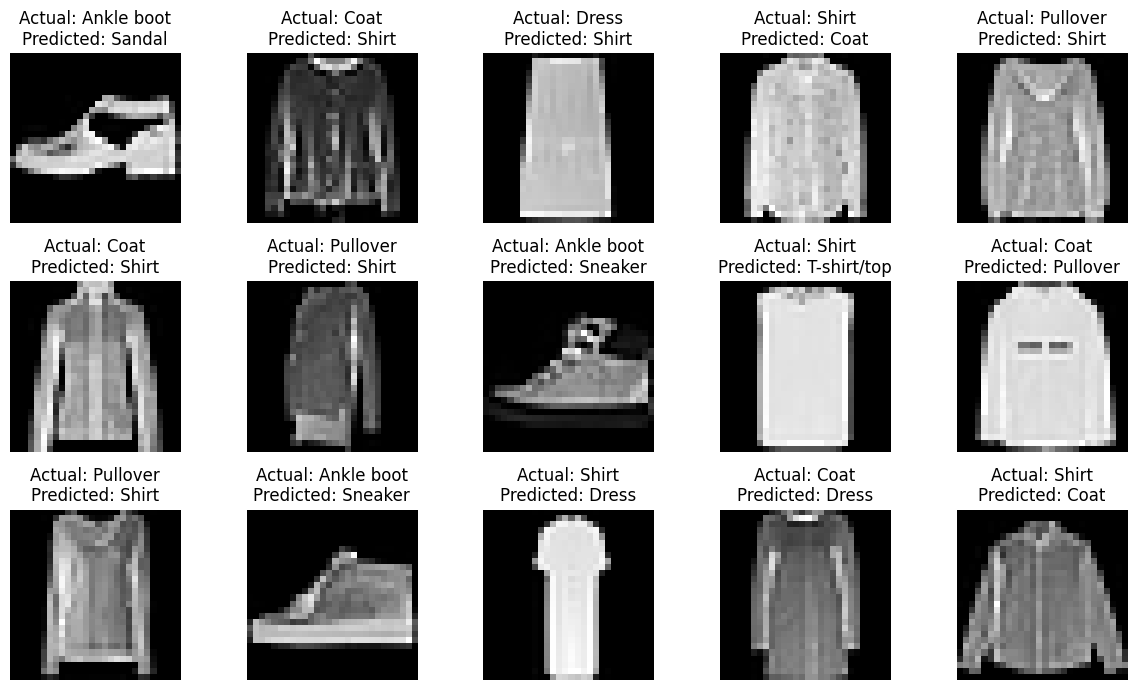

Total Misclassified: 931
Model saved successfully.


In [ ]:
wrong = np.where(y_test != y_pred)[0]

plt.figure(figsize=(12,7))

for i in range(min(15, len(wrong))):
    idx = wrong[i]
    plt.subplot(3,5,i+1)
    plt.imshow(X_test[idx].reshape(28,28), cmap="gray")
    plt.title("Actual: " + classes[y_test[idx]] +
              "\nPredicted: " + classes[y_pred[idx]])
    plt.axis("off")

plt.tight_layout()
plt.show()

model.save("Fashion_MNIST_CNN.keras")

print("Total Misclassified:", len(wrong))
print("Model saved successfully.")